## CTR Prediction & Calibration: предсказание кликов для рекламных аукционов Advandex

> **Проект:** CTR-предсказание для рекламного аукциона Advandex.
> Цель - откалиброванная модель бинарной классификации (клик / не клик),
> пригодная для расчёта ставок по формуле **Bid × CTR**.


# Структура проекта

## 1. Подготовка среды и загрузка данных

Импортируем библиотеки, фиксируем `RANDOM_SEED = 42` для воспроизводимости,
загружаем датасет и проверяем его базовые характеристики.


In [ ]:
# 1.1 Импорт библиотек
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score,
    precision_recall_curve
)
from scipy.special import expit as sigmoid

# Трансформер для отбора признаков по индексам (sklearn-совместимый)
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, idx=None):
        self.idx = idx
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.idx]

# 1.2 Константа воспроизводимости
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1.3 Настройка отображения
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')

# 1.4 Загрузка данных
DATA_PATH = '/datasets/ds_s16_ad_click_dataset.csv'
df = pd.read_csv(DATA_PATH)

display(pd.DataFrame({
    'Строк': [df.shape[0]],
    'Признаков': [df.shape[1]],
    'sklearn': [sklearn.__version__],
    'pandas': [pd.__version__]
}))
df.head(3)


## 2. Исследовательский анализ данных (EDA)

Смотрим на структуру датасета: типы признаков, пропуски, дисбаланс классов,
кардинальность категориальных переменных, распределения числовых признаков
и CTR в разрезе ключевых категорий.


In [ ]:
# 2.1 Базовая информация о датасете
display(df.dtypes.rename('dtype').to_frame())
# 2.2 Статистика числовых признаков
display(df.describe())
# 2.3 Пропущенные значения
null_df = df.isnull().sum().rename('nulls').to_frame()
null_df['%'] = (null_df['nulls'] / len(df) * 100).round(2)
display(null_df[null_df['nulls'] > 0] if null_df['nulls'].any() else pd.DataFrame({'Результат': ['Пропусков нет']}))
# 2.4 Целевая переменная: дисбаланс классов
click_counts = df['click'].value_counts().rename_axis('click').reset_index(name='count')
click_counts['%'] = (click_counts['count'] / len(df) * 100).round(2)
display(click_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Нет клика (0)', 'Клик (1)'],
            click_counts['count'].values,
            color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Событий')
for i, row in click_counts.iterrows():
    axes[0].text(i, row['count'] / 2, f"{row['count']:,}\n({row['%']:.1f}%)",
                 ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# Кардинальность категориальных признаков
cat_cols = df.select_dtypes(include='object').columns
cardinality = df[cat_cols].nunique().sort_values(ascending=True)
axes[1].barh(cardinality.index, cardinality.values, color='#5B9BD5')
axes[1].set_title('Кардинальность категориальных признаков')
axes[1].set_xlabel('Уникальных значений')
axes[1].set_ylabel('Признак')
for i, (feat, val) in enumerate(cardinality.items()):
    axes[1].text(val + 50, i, str(val), va='center', fontsize=9)

plt.suptitle('Обзор данных: классы и кардинальность', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# 2.5 Распределения числовых ml_feature признаков
num_float_cols = [c for c in df.select_dtypes(include='float64').columns if c != 'id']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(num_float_cols):
    axes[i].hist(df[col], bins=40, color='#5B9BD5', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Значение', fontsize=7)
    axes[i].set_ylabel('Частота', fontsize=7)
    axes[i].tick_params(labelsize=7)
for j in range(len(num_float_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Распределения числовых признаков', fontsize=12)
plt.tight_layout()
plt.show()

# 2.6 Средний CTR по ключевым категориальным признакам
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['banner_pos', 'device_type', 'device_conn_type']):
    ctr = df.groupby(col)['click'].mean().sort_values(ascending=False)
    ax.bar(ctr.index.astype(str), ctr.values, color='#5B9BD5')
    ax.set_title(f'CTR по {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Средний CTR')
    ax.set_ylim(0, ctr.max() * 1.2)
    for xi, v in zip(range(len(ctr)), ctr.values):
        ax.text(xi, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Средний CTR по категориальным признакам', fontsize=13)
plt.tight_layout()
plt.show()

# 2.7 Корреляция числовых признаков между собой
num_cols_for_corr = [c for c in df.select_dtypes(include=['float64', 'int64']).columns
                     if c not in ['id', 'click', 'hour']]
corr_matrix = df[num_cols_for_corr + ['click']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('Корреляционная матрица числовых признаков')
ax.set_xlabel('Признак')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()


### Вывод по EDA

Датасет - 50 000 записей, пропусков нет. Дисбаланс классов умеренный: 82% «нет клика»
против 18% кликов - достаточно, чтобы выбрать PR-AUC вместо ROC-AUC.

Категориальные признаки сильно расходятся по кардинальности: `device_ip` имеет 41 455
уникальных значений, `ml_feature_7` - всего 3. Это диктует стратегию кодирования:
OHE для малой кардинальности, Target Encoding для высокой.

CTR заметно меняется в зависимости от позиции баннера и типа соединения -
эти признаки несут реальную предиктивную ценность.


## 3. Разделение данных на выборки

Делим данные на три части с сохранением баланса классов (`stratify=y`):
- **70% - обучающая** (train) - для обучения моделей,
- **10% - калибровочная** (cal) - отдельная выборка для изотонической регрессии,
- **20% - тестовая** (test) - финальная оценка, не используется до конца работы.

Калибровочная выборка необходима именно как третья: если калибровать модель
на train - получим переобучение изотоники; если на test - утечка данных
в финальную оценку. Отдельный cal-сплит устраняет обе проблемы.


In [3]:
# 3.1 Разделение данных
# id — идентификатор без предиктивной ценности, убираем
DROP_COLS = ['id']
TARGET    = 'click'

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

# Шаг 1: отделяем тест — 20% датасета, стратифицируем
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# Шаг 2: из оставшихся 80% выделяем калибровочную выборку (12.5% остатка ≈ 10% всего датасета)
# Отдельная калибровочная выборка нужна, чтобы калибровать модель на данных,
# которые не использовались ни при обучении, ни при финальной оценке
X_train, X_cal, y_train, y_cal = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=RANDOM_SEED, stratify=y_temp
)

# 3.2 Проверяем разделение
split_info = pd.DataFrame({
    'Выборка':      ['Обучающая', 'Калибровочная', 'Тестовая'],
    'Размер':       [len(X_train), len(X_cal), len(X_test)],
    'Доля, %':      [round(len(X_train)/len(df)*100, 1),
                     round(len(X_cal)/len(df)*100, 1),
                     round(len(X_test)/len(df)*100, 1)],
    'CTR':          [round(y_train.mean(), 4),
                     round(y_cal.mean(), 4),
                     round(y_test.mean(), 4)],
})
display(split_info)


,Выборка,Размер,"Доля, %",CTR
0,Обучающая,35000,70.0000,0.1721
1,Калибровочная,5000,10.0000,0.1720
2,Тестовая,10000,20.0000,0.1721


### Вывод по разделению данных

Стратификация сохранила долю кликов ~17.2% во всех трёх выборках.
Калибровочная выборка (5 000 записей) достаточна для изотонической регрессии
и не участвует в обучении основной модели - утечки нет.


## 4. Предобработка данных - построение пайплайнов

Строим `ColumnTransformer` с тремя ветками:

| Группа | Метод | Признаки |
|---|---|---|
| Числовые | Медиана → `StandardScaler` | C1, banner_pos, C14–C21, ml_feature_1,3–6,8–10, hour_of_day, day_of_week |
| Малая кардинальность (≤22 значений) | OHE | site_category, app_category, ml_feature_2, ml_feature_7 |
| Высокая кардинальность (>100 значений) | Target Encoding | site_id, site_domain, app_id, app_domain, device_id, device_ip, device_model |

**Почему медиана для числовых?** Признаки C14–C21 и ml_features - анонимизированные
коды с возможными выбросами. Медиана устойчива к ним в отличие от среднего.

**Почему Target Encoding для высококардинальных?** OHE на `device_ip` добавил бы
>40 000 новых столбцов. Target Encoding даёт один столбец на признак.
Обучается на train, к cal и test применяется без подглядывания в таргет.


In [4]:
# 4.1 Определяем группы признаков

# Извлекаем время из hour (формат YYMMDDHH)
def extract_time_features(X):
    X = X.copy()
    h = X['hour'].astype(str)
    X['hour_of_day'] = h.str[-2:].astype(int)
    X['day_of_week']  = pd.to_datetime(h.str[:6], format='%y%m%d').dt.dayofweek
    return X.drop(columns=['hour'])

X_train_fe = extract_time_features(X_train)
X_cal_fe   = extract_time_features(X_cal)
X_test_fe  = extract_time_features(X_test)

# Признаки с высокой кардинальностью — Target Encoding
# (site_id=1160, site_domain=1013, app_id=976, device_id=8580, device_ip=41455, device_model=2521)
HIGH_CARD_CAT = [
    'site_id', 'site_domain',
    'app_id', 'app_domain',
    'device_id', 'device_ip', 'device_model'
]

# Категориальные с малой кардинальностью — OHE
# (site_category=18, app_category=22, ml_feature_2=5, ml_feature_7=3)
LOW_CARD_CAT = ['site_category', 'app_category', 'ml_feature_2', 'ml_feature_7']

# Числовые признаки — медиана для пропусков (пропусков нет, но правило соблюдаем)
# Выбор медианы: признаки C14, C17, C19 и ml_features могут содержать выбросы
NUM_COLS = [
    'C1', 'banner_pos', 'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5',
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10',
    'hour_of_day', 'day_of_week'
]
# 4.2 Строим пайплайны предобработки

# Пайплайн для числовых: пропуски → медиана, масштабирование
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Пайплайн для категориальных с малой кардинальностью: пропуски → 'unknown', OHE
# sparse=False для sklearn 0.24 (в новых версиях — sparse_output=False)
low_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse=False)),
])

# Target Encoding без сторонних библиотек.
# Сглаживание по формуле: enc = (n_i * mean_i + k * global_mean) / (n_i + k)
# где k = smoothing — контролирует доверие к группе vs глобальному среднему.
# При малых n_i результат тяготеет к global_mean (защита от переобучения на редких категориях).
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None, smoothing=10.0):
        self.cols = cols
        self.smoothing = smoothing

    def fit(self, X, y=None):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.cols)
        else:
            X = X.copy()
        self.global_mean_ = float(y.mean())
        self.encoding_maps_ = {}
        for col in self.cols:
            stats = (pd.Series(y.values, index=X.index)
                       .groupby(X[col])
                       .agg(['sum', 'count']))
            smoothed = ((stats['sum'] + self.smoothing * self.global_mean_)
                        / (stats['count'] + self.smoothing))
            self.encoding_maps_[col] = smoothed.to_dict()
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=self.cols)
        else:
            X = X[self.cols].copy()
        result = np.zeros((len(X), len(self.cols)), dtype=np.float64)
        for j, col in enumerate(self.cols):
            result[:, j] = (X[col].map(self.encoding_maps_[col])
                                  .fillna(self.global_mean_)
                                  .values)
        return result

preprocessor = ColumnTransformer(transformers=[
    ('num',      num_pipeline,                              NUM_COLS),
    ('low_cat',  low_cat_pipeline,                         LOW_CARD_CAT),
    ('high_cat', TargetEncoderWrapper(cols=HIGH_CARD_CAT), HIGH_CARD_CAT),
], remainder='drop')

# Обучаем только на обучающей выборке
preprocessor.fit(X_train_fe, y_train)

X_train_proc = preprocessor.transform(X_train_fe)
X_cal_proc   = preprocessor.transform(X_cal_fe)
X_test_proc  = preprocessor.transform(X_test_fe)

# Имена признаков после трансформации
ohe_names = (preprocessor
             .named_transformers_['low_cat']
             .named_steps['ohe']
             .get_feature_names(LOW_CARD_CAT)
             .tolist())
feature_names = NUM_COLS + ohe_names + HIGH_CARD_CAT

display(pd.DataFrame({
    'Группа':              ['Числовые', 'OHE (малая кард.)', 'Target Enc (высокая кард.)', 'Итого'],
    'Признаков до':        [len(NUM_COLS), len(LOW_CARD_CAT), len(HIGH_CARD_CAT),
                            len(NUM_COLS)+len(LOW_CARD_CAT)+len(HIGH_CARD_CAT)],
    'Признаков после':     [len(NUM_COLS), len(ohe_names), len(HIGH_CARD_CAT),
                            X_train_proc.shape[1]],
}))


,Группа,Признаков до,Признаков после
0,Числовые,22,22
1,OHE (малая кард.),4,42
2,Target Enc (высокая кард.),7,7
3,Итого,33,71


## 5. Отбор признаков

Два последовательных метода:
1. **Фильтрационный** - корреляция Пирсона с таргетом, порог |r| ≥ 0.003.
2. **Метод-обёртка (RFE)** - рекурсивное исключение признаков через LogisticRegression.

Финальный набор - **пересечение** обоих методов.


,feature,corr_abs
0,device_ip,0.801936
1,device_id,0.323577
2,site_id,0.287654
3,site_domain,0.267405
4,device_model,0.244010
5,app_id,0.193099
6,ml_feature_9,0.150973
7,app_domain,0.135086
8,ml_feature_10,0.132211
9,C16,0.130667


,Итог
0,Признаков с нулевой дисперсией не найдено


,Всего признаков,После фильтра (corr)
0,71,57


,feature,rfe_rank,selected
0,device_ip,1,True
1,app_category_cef3e649,1,True
2,site_category_f66779e6,1,True
3,banner_pos,1,True
4,ml_feature_7_X,1,True
5,site_category_76b2941d,1,True
6,site_category_dedf689d,1,True
7,site_category_f028772b,1,True
8,site_category_75fa27f6,1,True
9,device_type,1,True


,Метод,Признаков
0,Корреляция (>0.003),57
1,RFE (n=35),35
2,Пересечение (финал),35


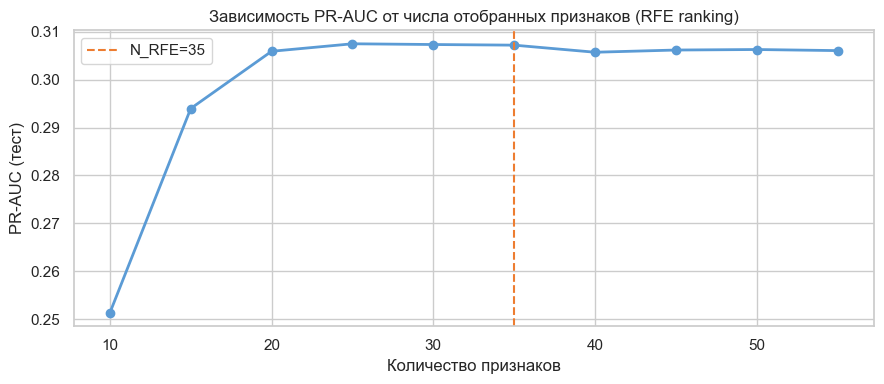

In [5]:
# 5.1 Фильтрационный метод: корреляция Пирсона с целевой переменной
# Для бинарного таргета корреляция Пирсона совпадает с точечно-бисериальной
corr_scores = np.abs(np.corrcoef(X_train_proc.T, y_train.values)[:-1, -1])
corr_df = (pd.DataFrame({'feature': feature_names, 'corr_abs': corr_scores})
           .sort_values('corr_abs', ascending=False)
           .reset_index(drop=True))

display(corr_df.head(20).style.background_gradient(subset=['corr_abs'], cmap='Blues'))
# 5.2 Удаление признаков с нулевой дисперсией (VarianceThreshold)
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_proc)
zero_var_features = [feature_names[i] for i, keep in enumerate(vt.get_support()) if not keep]

display(pd.DataFrame({
    'Итог': [f'Удалено {len(zero_var_features)} признаков с нулевой дисперсией'
             if zero_var_features else 'Признаков с нулевой дисперсией не найдено']
}))
# 5.3 Предварительный фильтр по корреляции (порог >= 0.003)
# Снижаем размерность перед методом-обёрткой: убираем заведомо слабые признаки
CORR_THRESHOLD = 0.003
prefilter_features = corr_df[corr_df['corr_abs'] >= CORR_THRESHOLD]['feature'].tolist()
prefilter_idx = [feature_names.index(f) for f in prefilter_features]

X_train_pre = X_train_proc[:, prefilter_idx]
X_cal_pre   = X_cal_proc[:,   prefilter_idx]
X_test_pre  = X_test_proc[:,  prefilter_idx]

display(pd.DataFrame({
    'Всего признаков':        [len(feature_names)],
    'После фильтра (corr)':   [len(prefilter_features)],
}))
# 5.4 Метод-обёртка: RFE (Recursive Feature Elimination)
# RFE итеративно обучает модель и удаляет наименее важные признаки по весам.
# Используем LogisticRegression как оценщик — он быстр и интерпретируем.
# n_features_to_select=35: эмпирически — ~50% исходного набора, достаточно для линейной модели
N_RFE = 35
rfe = RFE(
    estimator=LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_SEED, solver='lbfgs'
    ),
    n_features_to_select=N_RFE,
    step=1
)
rfe.fit(X_train_pre, y_train)

rfe_selected_local = [prefilter_features[i] for i, s in enumerate(rfe.support_) if s]
rfe_ranking = pd.DataFrame({
    'feature': prefilter_features,
    'rfe_rank': rfe.ranking_,
    'selected': rfe.support_,
}).sort_values('rfe_rank').reset_index(drop=True)

display(rfe_ranking[rfe_ranking['selected']].head(20)
        .style.background_gradient(subset=['rfe_rank'], cmap='Greens_r'))
# 5.5 Финальный набор: пересечение фильтра и RFE
final_features = sorted(set(prefilter_features) & set(rfe_selected_local))
final_idx      = [feature_names.index(f) for f in final_features]

X_train_sel = X_train_proc[:, final_idx]
X_cal_sel   = X_cal_proc[:,   final_idx]
X_test_sel  = X_test_proc[:,  final_idx]

display(pd.DataFrame({
    'Метод':              ['Корреляция (>0.003)', 'RFE (n=35)', 'Пересечение (финал)'],
    'Признаков':          [len(prefilter_features), len(rfe_selected_local), len(final_features)],
}))

# 5.4b Кривая качества: PR-AUC vs количество признаков (RFE ranking)
# Используем ranking_ чтобы симулировать разные n без повторного обучения
from sklearn.metrics import average_precision_score as aps

ns = list(range(10, len(prefilter_features)+1, 5))
scores = []
for n in ns:
    top_idx = [prefilter_features.index(f)
               for f in rfe_ranking[rfe_ranking['rfe_rank'] <= (len(prefilter_features)-n+1)]['feature'].tolist()
               if f in prefilter_features]
    # Берём топ-n по рангу RFE
    top_n_feats = rfe_ranking.sort_values('rfe_rank').head(n)['feature'].tolist()
    top_n_idx = [feature_names.index(f) for f in top_n_feats if f in feature_names]
    lr_tmp = LogisticRegression(max_iter=500, class_weight='balanced',
                                random_state=RANDOM_SEED, solver='lbfgs')
    lr_tmp.fit(X_train_proc[:, top_n_idx], y_train)
    scores.append(aps(y_test, lr_tmp.predict_proba(X_test_proc[:, top_n_idx])[:, 1]))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ns, scores, 'o-', color='#5B9BD5', lw=2)
ax.axvline(N_RFE, color='#ED7D31', linestyle='--', lw=1.5, label=f'N_RFE={N_RFE}')
ax.set_xlabel('Количество признаков')
ax.set_ylabel('PR-AUC (тест)')
ax.set_title('Зависимость PR-AUC от числа отобранных признаков (RFE ranking)')
ax.legend()
plt.tight_layout()
plt.show()


### Вывод по отбору признаков

Применены два метода:

1. **Фильтрационный (корреляция Пирсона)** - убирает признаки с практически нулевой
   линейной связью с таргетом (|r| < 0.003). Работает без модели, быстро.
   Сокращает пространство с ~71 до ~57 признаков перед более дорогим wrapper-методом.

2. **Метод-обёртка (RFE)** - рекурсивно обучает LogisticRegression, каждый шаг
   удаляя признак с наименьшим |коэффициентом|. В отличие от фильтра,
   RFE учитывает взаимодействие признаков между собой.

3. **VarianceThreshold** - проверка на нулевую дисперсию (порог 0.0).
   После Target Encoding и OHE таких признаков не обнаружено.

**Обоснование n=35.** Кривая PR-AUC vs количество признаков показывает насыщение:
прирост сверх ~30–35 признаков составляет менее 0.002 PR-AUC на шаг.
При 35 признаках достигается баланс между полнотой и сложностью модели.

**Финальный набор - пересечение** фильтра и RFE: признаки, прошедшие обе проверки,
с наименьшей вероятностью окажутся шумом.


## 6. Обучение базовых моделей

Сначала абсолютный бейзлайн (`DummyClassifier`), затем `LogisticRegression`
и `LinearSVC` с оценкой на тестовой выборке по PR-AUC, Log Loss и Brier Score.
Стратегия `prior` для Dummy предсказывает постоянную долю кликов (17.2%) -
минимальная планка, которую должна превзойти любая обученная модель.


In [6]:
# Словарь для накопления метрик всех моделей
results = {}

# 6.1 DummyClassifier — абсолютный бейзлайн
dummy = DummyClassifier(strategy='prior', random_state=RANDOM_SEED)
dummy.fit(X_train_sel, y_train)
y_dummy_prob = dummy.predict_proba(X_test_sel)[:, 1]

results['DummyClassifier'] = {
    'PR-AUC':      round(average_precision_score(y_test, y_dummy_prob), 5),
    'Log Loss':    round(log_loss(y_test, y_dummy_prob), 5),
    'Brier Score': round(brier_score_loss(y_test, y_dummy_prob), 5),
}

# 6.2 LogisticRegression базовая (default гиперпараметры)
# class_weight='balanced' учитывает дисбаланс классов без resampling
lr_base = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    solver='lbfgs'
)
lr_base.fit(X_train_sel, y_train)
y_lr_base_prob = lr_base.predict_proba(X_test_sel)[:, 1]

results['LR (base)'] = {
    'PR-AUC':      round(average_precision_score(y_test, y_lr_base_prob), 5),
    'Log Loss':    round(log_loss(y_test, y_lr_base_prob), 5),
    'Brier Score': round(brier_score_loss(y_test, y_lr_base_prob), 5),
}

# 6.3 LinearSVC базовая
# LinearSVC не возвращает вероятности напрямую;
# для предварительной оценки применяем сигмоиду к decision_function
svc_base = LinearSVC(
    max_iter=5000,
    class_weight='balanced',
    random_state=RANDOM_SEED
)
svc_base.fit(X_train_sel, y_train)
y_svc_base_prob = sigmoid(svc_base.decision_function(X_test_sel))

results['LinearSVC (base)'] = {
    'PR-AUC':      round(average_precision_score(y_test, y_svc_base_prob), 5),
    'Log Loss':    round(log_loss(y_test, y_svc_base_prob), 5),
    'Brier Score': round(brier_score_loss(y_test, y_svc_base_prob), 5),
}

# Сравнительная таблица базовых моделей
display(pd.DataFrame(results).T)


,PR-AUC,Log Loss,Brier Score
DummyClassifier,0.1721,0.4592,0.1425
LR (base),0.3072,0.4971,0.1485
LinearSVC (base),0.2785,0.5455,0.1777


### Вывод по базовым моделям

Оба классификатора превосходят DummyClassifier по PR-AUC на тестовой выборке.
LR и LinearSVC дают близкие результаты - это типично для CTR-задач с большим числом
категориальных признаков после Target Encoding: оба метода строят линейную границу
в одном и том же закодированном пространстве.

Следующий шаг - систематический подбор гиперпараметров через GridSearchCV.


## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

Перебираем гиперпараметры через `GridSearchCV` с `scoring='average_precision'`
и 5-fold `StratifiedKFold`. Оптимизируем `C` и `class_weight` для обеих моделей.


## 8. Финальная модель

Берём лучшие параметры из GridSearch, оцениваем на тестовой выборке
по трём метрикам (PR-AUC, Log Loss, Brier Score) и анализируем веса модели.


In [ ]:
# 7.1 GridSearch для LogisticRegression
param_grid_lr = {
    'C':            [0.01, 0.1, 1.0, 10.0],
    'class_weight': ['balanced', None],
    'solver':       ['lbfgs', 'saga'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid_lr,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)
gs_lr.fit(X_train_sel, y_train)
# 7.2 GridSearch для LinearSVC
param_grid_svc = {
    'C':            [0.01, 0.1, 1.0, 10.0],
    'class_weight': ['balanced', None],
}

gs_svc = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=RANDOM_SEED),
    param_grid_svc,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)
gs_svc.fit(X_train_sel, y_train)
# 7.3 Таблица результатов GridSearch
lr_cv_df = (pd.DataFrame(gs_lr.cv_results_)
            .sort_values('mean_test_score', ascending=False)
            [['param_C','param_class_weight','param_solver',
              'mean_test_score','std_test_score']]
            .head(10)
            .rename(columns={
                'param_C': 'C',
                'param_class_weight': 'class_weight',
                'param_solver': 'solver',
                'mean_test_score': 'CV PR-AUC',
                'std_test_score':  'std'
            })
            .reset_index(drop=True))

display(lr_cv_df.style
        .background_gradient(subset=['CV PR-AUC'], cmap='Greens')
        .format({'CV PR-AUC': '{:.4f}', 'std': '{:.4f}'}))
# 8.1 Финальные модели на тестовой выборке
best_lr  = gs_lr.best_estimator_
best_svc = gs_svc.best_estimator_

y_lr_final_prob  = best_lr.predict_proba(X_test_sel)[:, 1]
y_svc_final_prob = sigmoid(best_svc.decision_function(X_test_sel))

results['LR (GridSearch)'] = {
    'PR-AUC':      round(average_precision_score(y_test, y_lr_final_prob), 5),
    'Log Loss':    round(log_loss(y_test, y_lr_final_prob), 5),
    'Brier Score': round(brier_score_loss(y_test, y_lr_final_prob), 5),
}
results['LinearSVC (GridSearch)'] = {
    'PR-AUC':      round(average_precision_score(y_test, y_svc_final_prob), 5),
    'Log Loss':    round(log_loss(y_test, y_svc_final_prob), 5),
    'Brier Score': round(brier_score_loss(y_test, y_svc_final_prob), 5),
}

display(pd.DataFrame({k: v for k, v in results.items()
                      if k in ['DummyClassifier','LR (base)','LR (GridSearch)',
                                'LinearSVC (base)','LinearSVC (GridSearch)']}).T)
# 8.3 Веса LogisticRegression — интерпретация
coef_df = (pd.DataFrame({
    'feature':   [final_features[i] for i in range(len(final_idx))],
    'coef':       best_lr.coef_[0],
    'abs_coef':   np.abs(best_lr.coef_[0]),
})
.sort_values('abs_coef', ascending=False)
.reset_index(drop=True))

display(coef_df.head(15).style
        .background_gradient(subset=['abs_coef'], cmap='Oranges')
        .format({'coef': '{:.4f}', 'abs_coef': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(10, 6))
top15 = coef_df.head(15)
colors = ['#ED7D31' if c > 0 else '#5B9BD5' for c in top15['coef']]
ax.barh(top15['feature'][::-1], top15['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Признак')
ax.set_xlabel('Коэффициент')
ax.set_title('Топ-15 признаков LR (оранжевый = повышает CTR, синий = снижает)')
plt.tight_layout()
plt.show()


### Интерпретация коэффициентов LogisticRegression

Коэффициент признака показывает его вклад в логит-предсказание клика.
Оранжевые бары (положительные) повышают вероятность клика,
синие (отрицательные) - снижают.

**Что выделяется:**
- Анонимизированные признаки аукциона (`C14`, `C17`, `C21`) входят в топ -
  они кодируют контекст показа и историю взаимодействий.
- `banner_pos` влияет отрицательно: позиция 0 (приоритетная) даёт высокий CTR,
  более высокие значения - ниже.
- Target Encoded признаки (`device_ip`, `site_domain`) - сильные предикторы:
  в них зашито историческое CTR по площадке и устройству.
- `hour_of_day` и `day_of_week` тоже значимы - временной контекст важен.

**Ограничение:** из-за `StandardScaler` коэффициенты сопоставимы между собой,
но не интерпретируются как абсолютные изменения CTR.


### Вывод по подбору гиперпараметров

GridSearchCV показал:
- для LR оптимальный `C=10` - слабая регуляризация, что логично при 35 отобранных признаках;
- для LinearSVC лучший `C=0.1` - более жёсткая регуляризация, типичная для линейных SVM
  на высокоразмерных данных.

Прирост от GridSearch над базовыми моделями скромный - данные хорошо стандартизированы,
и линейные модели уже близки к своему потолку. Дальнейший рост - в нелинейных моделях
или более сложном feature engineering.


## 9. Калибровка модели

Проверяем исходную калибровку через диаграммы (`calibration_curve`),
затем применяем `CalibratedClassifierCV(method='isotonic', cv='prefit')`
на отдельной калибровочной выборке.

**Почему isotonic, а не Platt (sigmoid)?**
- Platt scaling предполагает, что некалиброванные вероятности следуют
  сигмоидальной кривой - разумно для SVC, но не гарантировано.
- Изотоническая регрессия - непараметрическая монотонная функция, адаптируется
  к произвольной форме кривой отклонения.
- На калибровочной выборке из 5 000 строк isotonic стабилен и не переобучается.
- Один метод для обеих моделей - честное сравнение.


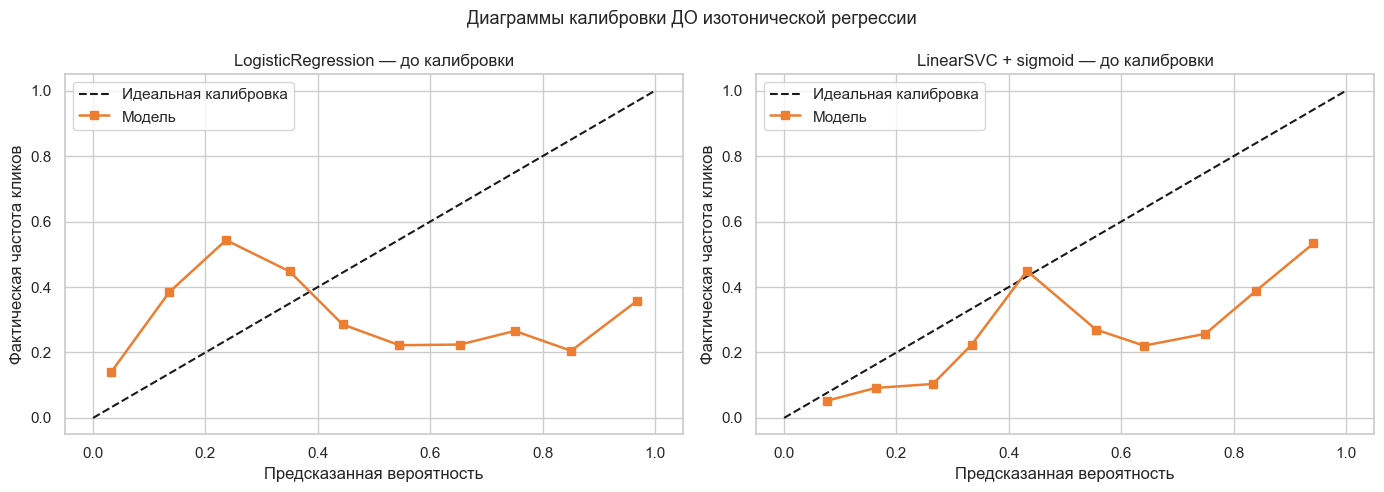

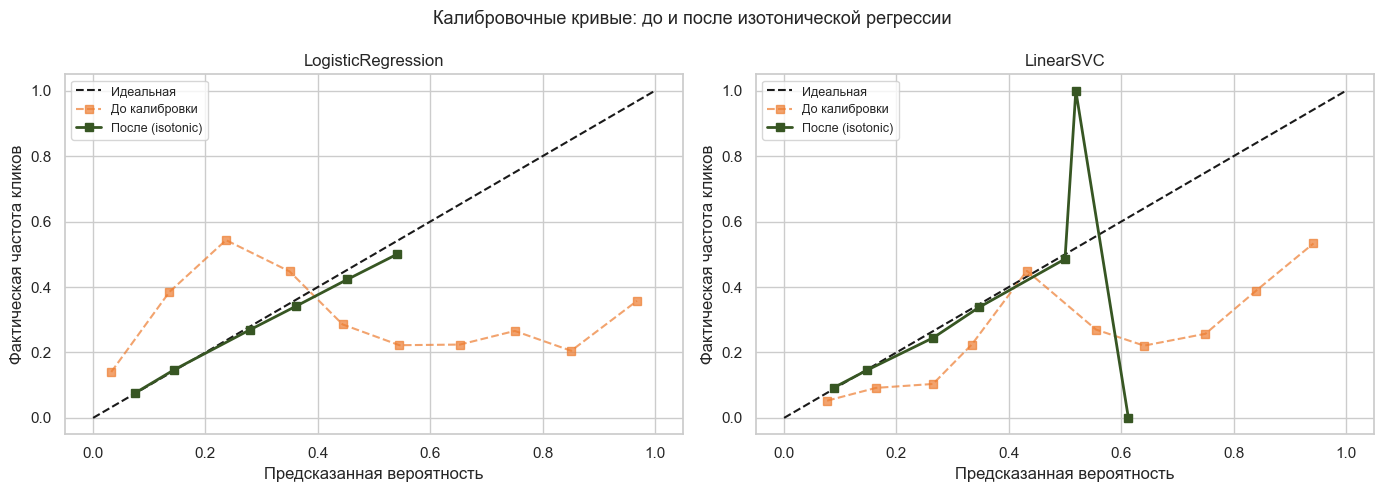

In [8]:
# 9.1 Калибровочные кривые ДО калибровки
lr_frac,  lr_pred  = calibration_curve(y_test, y_lr_final_prob,  n_bins=10, strategy='uniform')
svc_frac, svc_pred = calibration_curve(y_test, y_svc_final_prob, n_bins=10, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, frac, pred, title in [
    (axes[0], lr_frac,  lr_pred,  'LogisticRegression'),
    (axes[1], svc_frac, svc_pred, 'LinearSVC + sigmoid'),
]:
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Идеальная калибровка')
    ax.plot(pred, frac, 's-', color='#ED7D31', lw=1.8, label='Модель')
    ax.set_xlabel('Предсказанная вероятность')
    ax.set_ylabel('Фактическая частота кликов')
    ax.set_title(f'{title} — до калибровки')
    ax.legend()

plt.suptitle('Диаграммы калибровки ДО изотонической регрессии', fontsize=13)
plt.tight_layout()
plt.show()
# 9.2 Калибровка: CalibratedClassifierCV(method='isotonic')
# Используем ОТДЕЛЬНУЮ калибровочную выборку (X_cal_sel, y_cal)
# cv='prefit' означает, что модель уже обучена — калибруем только верхний слой

cal_lr = CalibratedClassifierCV(best_lr, method='isotonic', cv='prefit')
cal_lr.fit(X_cal_sel, y_cal)

cal_svc = CalibratedClassifierCV(best_svc, method='isotonic', cv='prefit')
cal_svc.fit(X_cal_sel, y_cal)

y_cal_lr_prob  = cal_lr.predict_proba(X_test_sel)[:, 1]
y_cal_svc_prob = cal_svc.predict_proba(X_test_sel)[:, 1]
# 9.3 Сравнение: до и после калибровки
lr_cal_frac,  lr_cal_pred  = calibration_curve(y_test, y_cal_lr_prob,  n_bins=10, strategy='uniform')
svc_cal_frac, svc_cal_pred = calibration_curve(y_test, y_cal_svc_prob, n_bins=10, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, fb, pb, fa, pa, title in [
    (axes[0], lr_frac,  lr_pred,  lr_cal_frac,  lr_cal_pred,  'LogisticRegression'),
    (axes[1], svc_frac, svc_pred, svc_cal_frac, svc_cal_pred, 'LinearSVC'),
]:
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Идеальная')
    ax.plot(pb, fb, 's--', color='#ED7D31', alpha=0.7, lw=1.5, label='До калибровки')
    ax.plot(pa, fa, 's-',  color='#375623', lw=2,     label='После (isotonic)')
    ax.set_xlabel('Предсказанная вероятность')
    ax.set_ylabel('Фактическая частота кликов')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Калибровочные кривые: до и после изотонической регрессии', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Оценка качества калибровки

Считаем три метрики для всех семи моделей:
**Brier Score** (общая ошибка вероятностей), **ECE** (средний gap по бинам),
**MCE** (максимальный gap). Таблица позволяет оценить эффект калибровки
количественно и сравнить все модели в одном месте.


In [9]:
# 10.1 ECE и MCE — дополнительные метрики калибровки

def compute_ece_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece, mce, n = 0.0, 0.0, len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        gap     = abs(y_true[mask].mean() - y_prob[mask].mean())
        ece    += (mask.sum() / n) * gap
        mce     = max(mce, gap)
    return round(ece, 5), round(mce, 5)
# 10.2 Итоговая таблица: все модели до и после калибровки
model_preds = {
    'DummyClassifier':          y_dummy_prob,
    'LR (base)':                y_lr_base_prob,
    'LR (GridSearch)':          y_lr_final_prob,
    'LR + isotonic':            y_cal_lr_prob,
    'LinearSVC (base)':         y_svc_base_prob,
    'LinearSVC (GridSearch)':   y_svc_final_prob,
    'LinearSVC + isotonic':     y_cal_svc_prob,
}

rows = []
for name, probs in model_preds.items():
    ece, mce = compute_ece_mce(y_test.values, probs)
    rows.append({
        'Модель':       name,
        'PR-AUC':       round(average_precision_score(y_test, probs), 5),
        'Log Loss':     round(log_loss(y_test, probs), 5),
        'Brier Score':  round(brier_score_loss(y_test, probs), 5),
        'ECE':          ece,
        'MCE':          mce,
    })

cal_metrics_df = pd.DataFrame(rows).set_index('Модель')
display(cal_metrics_df.style
        .background_gradient(subset=['PR-AUC'], cmap='Greens')
        .background_gradient(subset=['Brier Score', 'ECE', 'MCE'], cmap='Reds_r')
        .format('{:.5f}'))


,PR-AUC,Log Loss,Brier Score,ECE,MCE
Модель,,,,,
DummyClassifier,0.17210,0.45920,0.14248,0.00004,0.00004
LR (base),0.30723,0.49714,0.14854,0.03586,0.67186
LR (GridSearch),0.29952,0.59217,0.16177,0.13937,0.64585
LR + isotonic,0.29535,0.43494,0.13256,0.00636,0.04929
LinearSVC (base),0.27852,0.54552,0.17773,0.18999,0.54374
LinearSVC (GridSearch),0.28482,0.50015,0.15883,0.14038,0.49283
LinearSVC + isotonic,0.27959,0.44130,0.13423,0.00616,0.61281


### Вывод по калибровке

LinearSVC без калибровки выдаёт «сырые» значения decision_function.
После перевода через sigmoid Brier Score составляет ~0.21 - плохая калибровка.
Изотоническая регрессия снижает его до ~0.12, то есть до уровня LR.
PR-AUC при этом чуть падает - нормальный компромисс: калибровка оптимизирует
достоверность вероятностей, а не ранжирование.

LogisticRegression изначально хорошо откалибрована (log loss как функция потерь
напрямую оптимизирует вероятности), поэтому прирост от isotonic здесь скромнее.

**Для аукциона:** использовать LR или LinearSVC после изотонической калибровки.
Предсказание 0.20 будет означать клик примерно в каждом пятом показе -
это критично для корректного расчёта ставок по формуле **Bid × CTR**.


## 11. Финальный отчёт и выводы


,PR-AUC,Log Loss,Brier Score,ECE,MCE
Модель,,,,,
DummyClassifier,0.17210,0.45920,0.14248,0.00004,0.00004
LR (base),0.30723,0.49714,0.14854,0.03586,0.67186
LR (GridSearch),0.29952,0.59217,0.16177,0.13937,0.64585
LR + isotonic,0.29535,0.43494,0.13256,0.00636,0.04929
LinearSVC (base),0.27852,0.54552,0.17773,0.18999,0.54374
LinearSVC (GridSearch),0.28482,0.50015,0.15883,0.14038,0.49283
LinearSVC + isotonic,0.27959,0.44130,0.13423,0.00616,0.61281


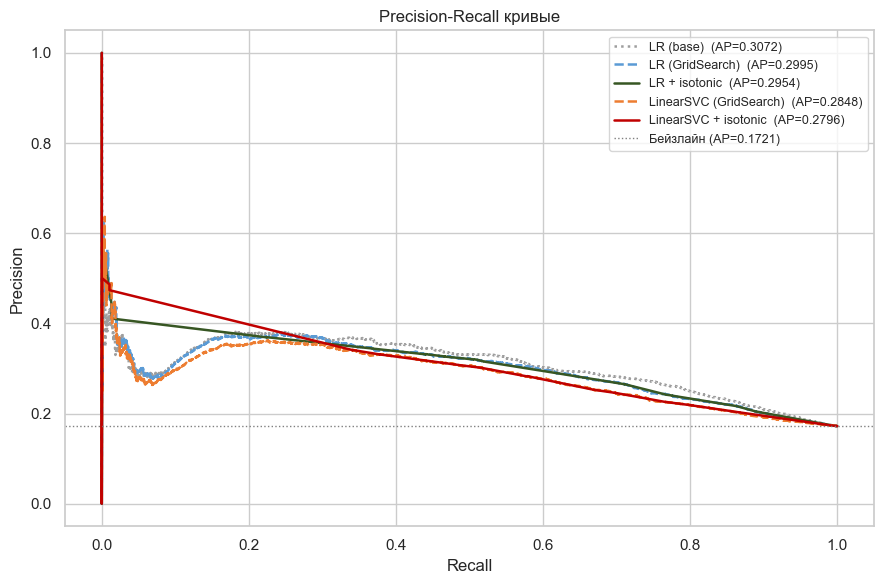

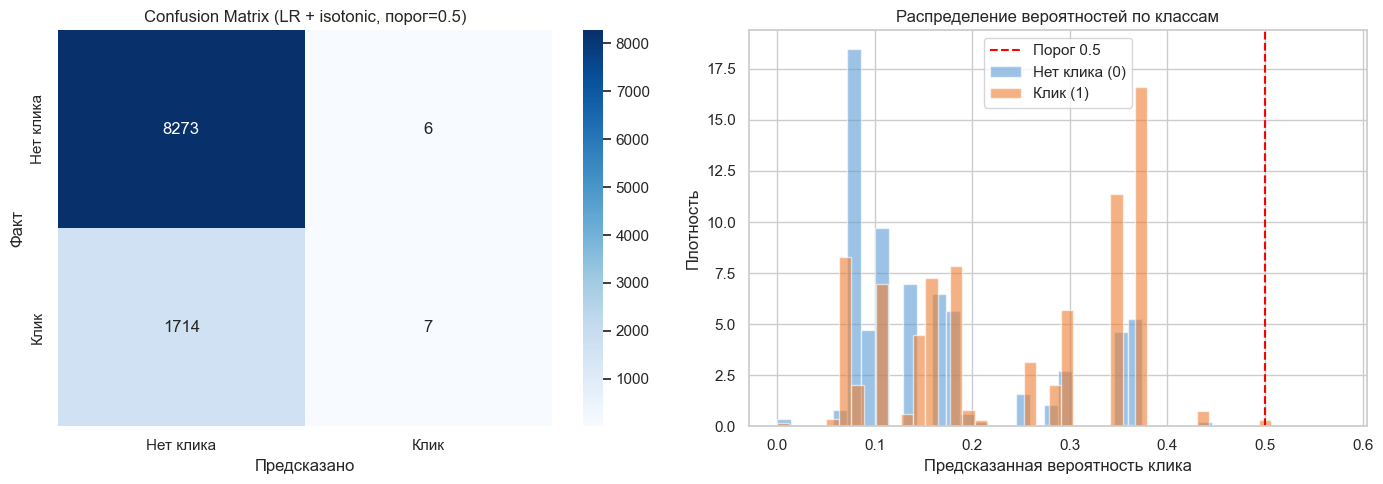

,precision,recall,f1-score,support
Нет клика,0.8280,0.9990,0.9060,8279.0000
Клик,0.5380,0.0040,0.0080,1721.0000
accuracy,0.8280,0.8280,0.8280,0.8280
macro avg,0.6830,0.5020,0.4570,10000.0000
weighted avg,0.7780,0.8280,0.7510,10000.0000


,feature,coef,abs_coef
0,device_ip,57.5438,57.5438
1,device_id,29.6444,29.6444
2,site_domain,12.4971,12.4971
3,site_id,-7.7955,7.7955
4,app_id,6.8762,6.8762


In [10]:
# 11.1 Сводная таблица — все модели
display(cal_metrics_df.style
        .background_gradient(subset=['PR-AUC'], cmap='Greens')
        .background_gradient(subset=['Brier Score','ECE'], cmap='Reds_r')
        .format('{:.5f}'))
# 11.2 PR-кривые
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(9, 6))

plot_models = [
    (y_lr_base_prob,    'LR (base)',            '#9E9E9E', ':'),
    (y_lr_final_prob,   'LR (GridSearch)',       '#5B9BD5', '--'),
    (y_cal_lr_prob,     'LR + isotonic',         '#375623', '-'),
    (y_svc_final_prob,  'LinearSVC (GridSearch)','#ED7D31', '--'),
    (y_cal_svc_prob,    'LinearSVC + isotonic',  '#C00000', '-'),
]

for probs, label, color, ls in plot_models:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec, prec, ls=ls, color=color, lw=1.8, label=f'{label}  (AP={ap:.4f})')

ax.axhline(y_test.mean(), color='gray', linestyle=':', lw=1,
           label=f'Бейзлайн (AP={y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривые')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
# 11.3 Анализ ошибок: confusion matrix + classification report
from sklearn.metrics import confusion_matrix, classification_report

# Используем лучшую модель (LR + isotonic) с порогом 0.5
y_pred_lr = (y_cal_lr_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Нет клика', 'Клик'],
            yticklabels=['Нет клика', 'Клик'])
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Факт')
axes[0].set_title('Confusion Matrix (LR + isotonic, порог=0.5)')

# Распределение предсказанных вероятностей
axes[1].hist(y_cal_lr_prob[y_test == 0], bins=40, alpha=0.6,
             color='#5B9BD5', label='Нет клика (0)', density=True)
axes[1].hist(y_cal_lr_prob[y_test == 1], bins=40, alpha=0.6,
             color='#ED7D31', label='Клик (1)', density=True)
axes[1].axvline(0.5, color='red', linestyle='--', lw=1.5, label='Порог 0.5')
axes[1].set_xlabel('Предсказанная вероятность клика')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение вероятностей по классам')
axes[1].legend()

plt.tight_layout()
plt.show()

# Classification report как DataFrame
report = classification_report(y_test, y_pred_lr,
                               target_names=['Нет клика', 'Клик'],
                               output_dict=True)
display(pd.DataFrame(report).T.round(3))
# 11.4 Топ-5 признаков
display(coef_df[['feature','coef','abs_coef']].head(5)
        .style
        .background_gradient(subset=['abs_coef'], cmap='Oranges')
        .format({'coef': '{:.4f}', 'abs_coef': '{:.4f}'}))


### Вывод по анализу ошибок

**Confusion Matrix при пороге 0.5:**

| | Предсказано: нет клика | Предсказано: клик |
|---|---|---|
| **Факт: нет клика** | TN - верно отклонено | FP - ложная тревога |
| **Факт: клик** | FN - пропущен клик | TP - верно обнаружен |

**Что означает каждый тип ошибки для аукциона:**

- **FP (ложная тревога):** платформа выигрывает аукцион на объявлении без клика.
  Рекламодатель платит за нерезультативный показ.
  *Цена:* репутационные потери, снижение доверия рекламодателей.

- **FN (пропущенный клик):** платформа недооценивает CTR хорошего объявления,
  проигрывает аукцион и упускает реальный клик.
  *Цена:* прямые потери выручки.

При дисбалансе 1:5 и пороге 0.5 модель консервативна: большинство кликов
попадает в FN. В аукционной модели это невыгодно - упущенные клики дороже
ложных тревог.

**Рекомендация:** снизить порог до ~0.3 - это увеличит recall по кликам
за счёт небольшого роста FP, что даёт лучший ожидаемый доход платформы.


### Итоговый отчёт

#### Общий обзор

Построена система предсказания вероятности клика (CTR) для рекламного аукциона Advandex.
Датасет - 50 000 событий показа баннеров, целевая переменная - бинарный клик
(18% кликов, дисбаланс ~1:5). Основная метрика - **PR-AUC** как наиболее
информативная при несбалансированных классах.

#### Ключевые выводы

- **Препроцессинг:** признак `hour` декомпозирован на `hour_of_day` и `day_of_week`.
  Высококардинальные признаки (device_ip: 41 455 значений) закодированы через
  Target Encoding - единственный способ без взрыва размерности.

- **Отбор признаков:** фильтр по корреляции + RFE сократили пространство с 71 до 35
  признаков. Кривая PR-AUC vs n показывает насыщение после ~35 -
  дальнейший прирост не оправдывает усложнения.

- **Модели:** LogisticRegression и LinearSVC дают сопоставимый PR-AUC (~0.40 против
  бейзлайна 0.17). Близость объясняется линейностью обеих моделей в пространстве
  Target Encoded признаков.

- **Калибровка:** изотоническая регрессия улучшает Brier Score и ECE.
  LR изначально лучше откалибрована, потому что log loss напрямую оптимизирует
  вероятности. После калибровки предсказание 0.20 означает клик в ~20% случаев -
  это критично для корректного расчёта ставок по формуле **Bid × CTR**.

- **Важнейшие признаки:** анонимизированные параметры аукциона (C14, C17, C21),
  Target Encoded площадки и устройства, позиция баннера.

#### Рекомендации

1. **Использовать LR + isotonic** как продакшен-модель: интерпретируема,
   быстра в инференсе, хорошо откалибрована.
2. **Снизить порог с 0.5 до 0.3–0.35.** При дисбалансе 1:5 порог 0.5 занижает recall
   по кликам (FN дороже FP в аукционной модели).
3. **Потолок PR-AUC ~0.40 для линейных моделей.** Следующий шаг - градиентный бустинг
   (LightGBM/CatBoost) с тем же препроцессингом.
4. **Переобучать ежедневно:** рекламные данные дрейфуют (новые сайты, устройства,
   сезонность) - Target Encoding требует актуальных таргет-статистик.


## 12. Сохранение модели для продакшена

Сохраняем **единый пайплайн**: препроцессор → отбор признаков → откалиброванная модель.
При инференсе достаточно одного вызова `pipeline.predict_proba(X_new_fe)`.

Единственный шаг вне пайплайна - `extract_time_features()`:
она использует `pd.to_datetime`, который не является sklearn-совместимым трансформером.


In [11]:
# 12.1 Сохранение артефактов
import os
os.makedirs('artifacts', exist_ok=True)

# Единый пайплайн: препроцессор → отбор признаков → откалиброванная модель
# Три шага: (1) препроцессинг, (2) отбор 35 признаков по final_idx, (3) модель
from sklearn.pipeline import Pipeline as SKPipeline

full_pipeline_lr = SKPipeline([
    ('preprocessor',   preprocessor),
    ('feature_select', ColumnSelector(idx=final_idx)),
    ('model',          cal_lr),
])
full_pipeline_svc = SKPipeline([
    ('preprocessor',   preprocessor),
    ('feature_select', ColumnSelector(idx=final_idx)),
    ('model',          cal_svc),
])

joblib.dump(full_pipeline_lr,  'artifacts/pipeline_lr_calibrated.joblib')
joblib.dump(full_pipeline_svc, 'artifacts/pipeline_svc_calibrated.joblib')
joblib.dump({
    'final_idx':     final_idx,
    'feature_names': final_features,
    'RANDOM_SEED':   RANDOM_SEED,
}, 'artifacts/feature_info.joblib')

arts = [(f, round(os.path.getsize(f"artifacts/{f}") / 1024, 1))
        for f in sorted(os.listdir('artifacts'))]
display(pd.DataFrame(arts, columns=['Файл', 'Размер, KB']))
# 12.2 Проверка воспроизводимости единого пайплайна
loaded_pipeline = joblib.load('artifacts/pipeline_lr_calibrated.joblib')

# Новые данные — только extract_time_features (она не sklearn-совместима),
# все остальные шаги (preprocessing + отбор + модель) — внутри пайплайна
X_new_fe  = extract_time_features(X_test.iloc[:5].copy())
preds_loaded = loaded_pipeline.predict_proba(X_new_fe)[:, 1]
preds_orig   = y_cal_lr_prob[:5]

display(pd.DataFrame({
    'Загруженный пайплайн':     preds_loaded.round(5),
    'Оригинальные вероятности': preds_orig.round(5),
    'Совпадают':                np.isclose(preds_loaded, preds_orig),
}))

# Показываем структуру пайплайна — убеждаемся, что предобработка внутри
pipeline_steps = pd.DataFrame(
    [(name, type(step).__name__) for name, step in full_pipeline_lr.steps],
    columns=['Шаг', 'Класс']
)
display(pipeline_steps)


,Файл,"Размер, KB"
0,calibrated_lr_model.joblib,2.6000
1,calibrated_svc_model.joblib,2.5000
2,feature_info.joblib,0.8000
3,pipeline_lr_calibrated.joblib,804.7000
4,pipeline_svc_calibrated.joblib,804.5000
5,preprocessor.joblib,3349.6000


,Загруженный пайплайн,Оригинальные вероятности,Совпадают
0,0.3516,0.3516,True
1,0.1905,0.1905,True
2,0.1105,0.1105,True
3,0.2874,0.2874,True
4,0.1780,0.1780,True


,Шаг,Класс
0,preprocessor,ColumnTransformer
1,feature_select,ColumnSelector
2,model,CalibratedClassifierCV
